In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/retail_sales_dataset.csv")

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [2]:
print(df.info())
print(df.describe())
print(df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB
None
       Transaction ID         Age     Quantity  Price per Unit  Total Amount
count     1000.000000  1000.00000  1000.000000     1000.000000   1000.000000
mean       500.500000    41.39200     2.514000      179.890000    456.000000
std        288.819436    13.68143     1.132734      189.681356    559.997632
min          1.000000    

In [3]:
print(df.columns.tolist())

['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']


In [4]:
print("Missing values before cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [5]:
print("Duplicate rows before cleaning:", df.duplicated().sum())

Duplicate rows before cleaning: 0


In [6]:
df_cleaned = df.drop_duplicates().copy()

print("Rows before cleaning:", len(df))
print("Rows after removing duplicates:", len(df_cleaned))

Rows before cleaning: 1000
Rows after removing duplicates: 1000


In [7]:
numeric_columns = df_cleaned.select_dtypes(include=np.number).columns
categorical_columns = df_cleaned.select_dtypes(include="object").columns

for column in numeric_columns:
    df_cleaned[column] = df_cleaned[column].fillna(
        df_cleaned[column].median()
    )

for column in categorical_columns:
    if df_cleaned[column].isnull().sum() > 0:
        df_cleaned[column] = df_cleaned[column].fillna(
            df_cleaned[column].mode()[0]
        )

In [8]:
print("Missing values after cleaning:")
print(df_cleaned.isnull().sum())

Missing values after cleaning:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [9]:
df_cleaned["Date"] = pd.to_datetime(
    df_cleaned["Date"],
    errors="coerce"
)

print(df_cleaned["Date"].dtype)

datetime64[ns]


In [10]:
df_cleaned["Gender"] = (
    df_cleaned["Gender"]
    .astype(str)
    .str.strip()
    .str.title()
)

df_cleaned["Product Category"] = (
    df_cleaned["Product Category"]
    .astype(str)
    .str.strip()
    .str.title()
)

df_cleaned.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [11]:
print("Invalid ages:", (df_cleaned["Age"] <= 0).sum())
print("Invalid quantities:", (df_cleaned["Quantity"] <= 0).sum())
print("Invalid prices:", (df_cleaned["Price per Unit"] <= 0).sum())
print("Invalid total amounts:", (df_cleaned["Total Amount"] <= 0).sum())

Invalid ages: 0
Invalid quantities: 0
Invalid prices: 0
Invalid total amounts: 0


In [12]:
df_cleaned = df_cleaned[
    (df_cleaned["Age"] > 0) &
    (df_cleaned["Quantity"] > 0) &
    (df_cleaned["Price per Unit"] > 0) &
    (df_cleaned["Total Amount"] > 0)
].copy()

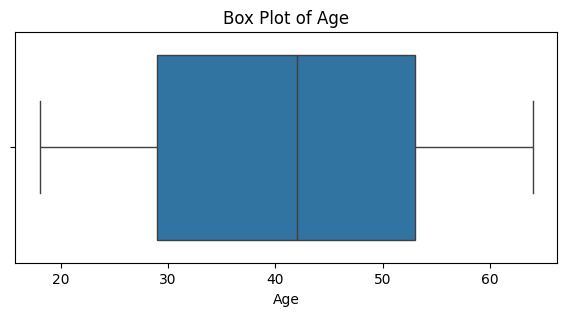

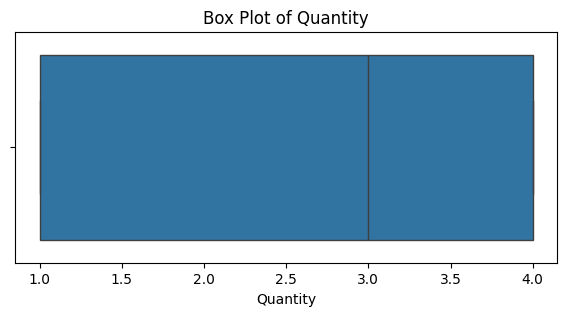

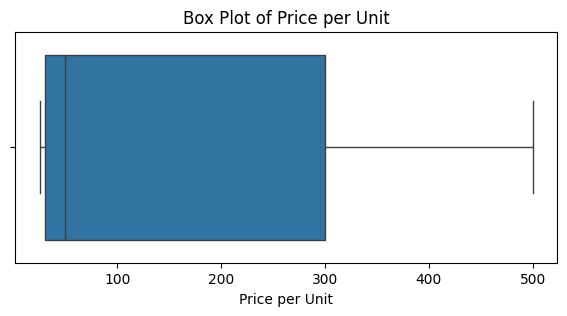

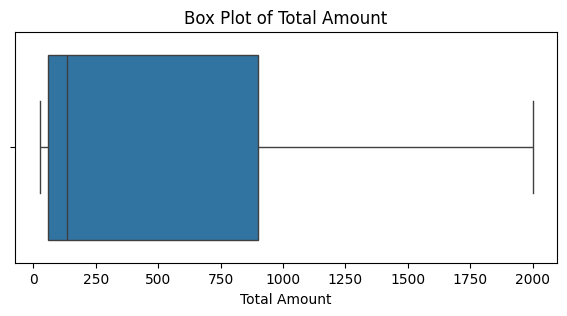

In [13]:
columns_to_check = [
    "Age",
    "Quantity",
    "Price per Unit",
    "Total Amount"
]

for column in columns_to_check:
    plt.figure(figsize=(7, 3))
    sns.boxplot(x=df_cleaned[column])
    plt.title(f"Box Plot of {column}")
    plt.show()

In [14]:
outlier_report = {}

for column in columns_to_check:
    q1 = df_cleaned[column].quantile(0.25)
    q3 = df_cleaned[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outliers = df_cleaned[
        (df_cleaned[column] < lower_limit) |
        (df_cleaned[column] > upper_limit)
    ]

    outlier_report[column] = len(outliers)

pd.Series(outlier_report, name="Number of Outliers")

,Number of Outliers
Age,0
Quantity,0
Price per Unit,0
Total Amount,0


In [15]:
comparison = pd.DataFrame({
    "Before Cleaning": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum()
    ],
    "After Cleaning": [
        df_cleaned.shape[0],
        df_cleaned.shape[1],
        df_cleaned.isnull().sum().sum(),
        df_cleaned.duplicated().sum()
    ]
}, index=[
    "Number of Rows",
    "Number of Columns",
    "Missing Values",
    "Duplicate Rows"
])

comparison

,Before Cleaning,After Cleaning
Number of Rows,1000,1000
Number of Columns,9,9
Missing Values,0,0
Duplicate Rows,0,0


In [16]:
df_cleaned.to_csv(
    "cleaned_retail_sales.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Conclusion

The retail sales dataset was checked for missing values, duplicate records, invalid values, inconsistent text formats and outliers.

Duplicate rows were removed, missing values were handled, the date column was converted into the correct format and categorical values were standardised.

Outliers were examined using box plots and the IQR method. Extreme values were retained when they appeared to represent valid retail transactions.

The cleaned dataset was saved as `cleaned_retail_sales.csv` and is ready for further analysis.